<a href="https://colab.research.google.com/github/aswathi-coder/python-employee-analysis/blob/main/Module1_End_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_excel("/content/drive/MyDrive/data files/ABC Company.xlsx")

In [4]:
df.dtypes

,0
Name,object
Team,object
Number,int64
Position,object
Age,int64
Height,object
Weight,int64
College,object
Salary,float64


In [5]:
print(df.head(5))

            Name            Team  Number Position  Age               Height  \
0  Avery Bradley  Boston Celtics       0       PG   25  2023-02-06 00:00:00   
1    Jae Crowder  Boston Celtics      99       SF   25  2023-06-06 00:00:00   
2   John Holland  Boston Celtics      30       SG   27  2023-05-06 00:00:00   
3    R.J. Hunter  Boston Celtics      28       SG   22  2023-05-06 00:00:00   
4  Jonas Jerebko  Boston Celtics       8       PF   29  2023-10-06 00:00:00   

   Weight            College     Salary  
0     180              Texas  7730337.0  
1     235          Marquette  6796117.0  
2     205  Boston University        NaN  
3     185      Georgia State  1148640.0  
4     231                NaN  5000000.0  


In [6]:
print(df.info)

<bound method DataFrame.info of               Name            Team  Number Position  Age               Height  \
0    Avery Bradley  Boston Celtics       0       PG   25  2023-02-06 00:00:00   
1      Jae Crowder  Boston Celtics      99       SF   25  2023-06-06 00:00:00   
2     John Holland  Boston Celtics      30       SG   27  2023-05-06 00:00:00   
3      R.J. Hunter  Boston Celtics      28       SG   22  2023-05-06 00:00:00   
4    Jonas Jerebko  Boston Celtics       8       PF   29  2023-10-06 00:00:00   
..             ...             ...     ...      ...  ...                  ...   
453   Shelvin Mack       Utah Jazz       8       PG   26  2023-03-06 00:00:00   
454      Raul Neto       Utah Jazz      25       PG   24  2023-01-06 00:00:00   
455   Tibor Pleiss       Utah Jazz      21        C   26  2023-03-07 00:00:00   
456    Jeff Withey       Utah Jazz      24        C   26                  7-0   
457       Priyanka       Utah Jazz      34        C   25  2023-03-07 00:00:00

In [7]:
df["Height"] = np.random.randint(150,180,size=len(df))
#print(df["Height"])
#print(df.head(5))
df.fillna(0, inplace=True) # Replace null values with 0
df.drop_duplicates(inplace=True) # Remove duplicate values.


#### Employee Distribution across each Team

In [8]:
# Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees.
emp_no = df["Team"].value_counts()
print(emp_no)
percentage_split = (emp_no/len(df))*100
print("\n Percentage split relative to the total number of employees")
print(percentage_split)




Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64

 Percentage split relative to the total number of employees
Team
New Orleans Pelicans      4.14847

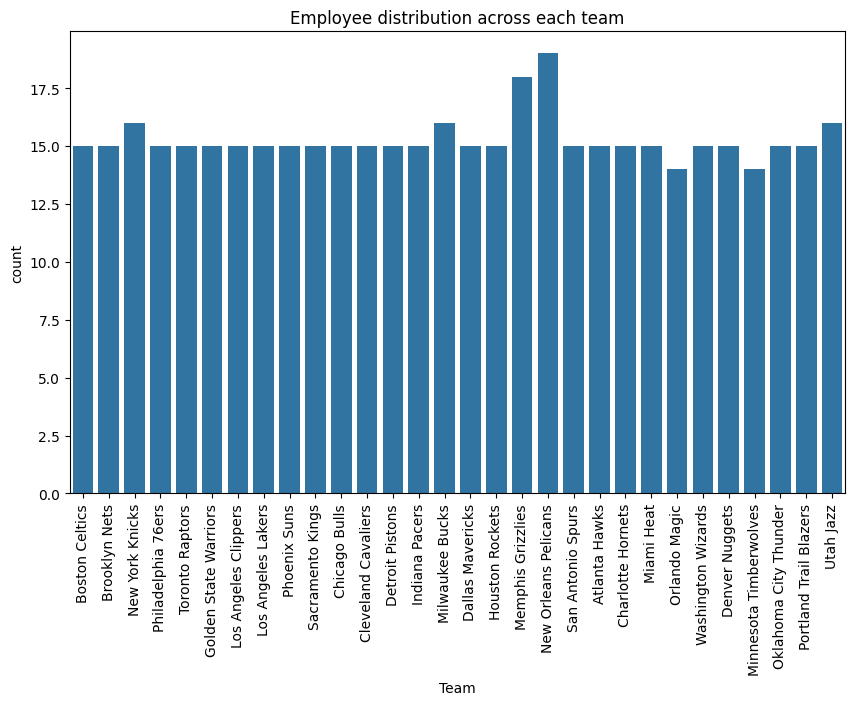

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Team")
plt.title("Employee distribution across each team")
plt.xticks(rotation=90)
plt.show()

Insights
* This shows how employees distributed accross different networks
* Higher bars show that the corresponding team has maximum workforce
* Departments can also understand the workforce details of each department


### Employee Segregation using their Position

In [10]:
# Segregate employees based on their positions within the company.
emp_position_distribution = df["Position"].value_counts()
print(emp_position_distribution)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


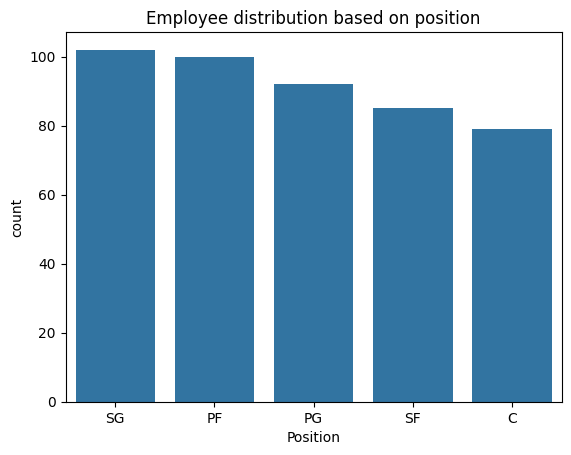

In [11]:
sns.countplot(data=df,x="Position",order=df["Position"].value_counts().index)
plt.title("Employee distribution based on position")
plt.show()

Insights
* Shows number of employees in each position
* Large bar shows the commonly required employees and small bar shows higher level employees.
* Shows organizational structure

### Predominant Age Group


In [12]:
# Identify the predominant age group among employees.
#print(max(df["Age"]))
#min(df["Age"])
bin=[19,25,30,35,40]
label=['19-25','26-30','31-35','36-40']
df["Age Group"]=pd.cut(df['Age'],bins=bin,labels=label)
age_group_distribution = df["Age Group"].value_counts().sort_index()
print("Age Group Distribution")
print(age_group_distribution)
print("\nPredominant Age Group is ",age_group_distribution.idxmax())

Age Group Distribution
Age Group
19-25    198
26-30    167
31-35     68
36-40     23
Name: count, dtype: int64

Predominant Age Group is  19-25


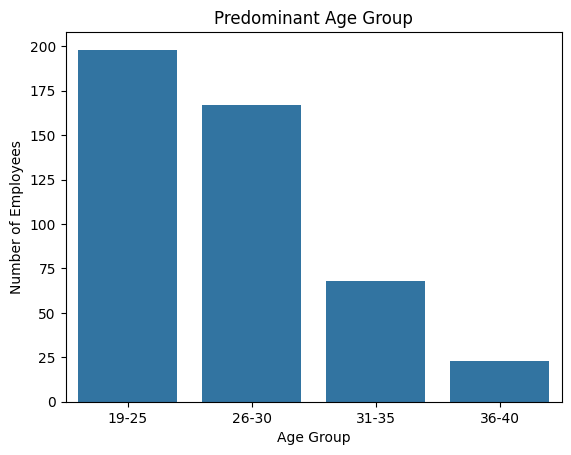

In [13]:
sns.countplot(data=df,x="Age Group")
plt.title("Predominant Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.show()

#### Insights
*

### Team and Position with Highest Salary Expenditure

In [45]:
# Discover which team and position have the highest salary expenditure.
#pd.set_option('display.max_rows', None)
salary_team_position = df.groupby(["Team","Position"])["Salary"].sum().reset_index()
print(salary_team_position.head(5))
print(salary_team_position.loc[ salary_team_position["Salary"].idxmax()])


            Team Position      Salary
0  Atlanta Hawks        C  22756250.0
1  Atlanta Hawks       PF  23952268.0
2  Atlanta Hawks       PG   9763400.0
3  Atlanta Hawks       SF   6000000.0
4  Atlanta Hawks       SG  10431032.0
Team        Los Angeles Lakers
Position                    SF
Salary              31866445.0
Name: 67, dtype: object


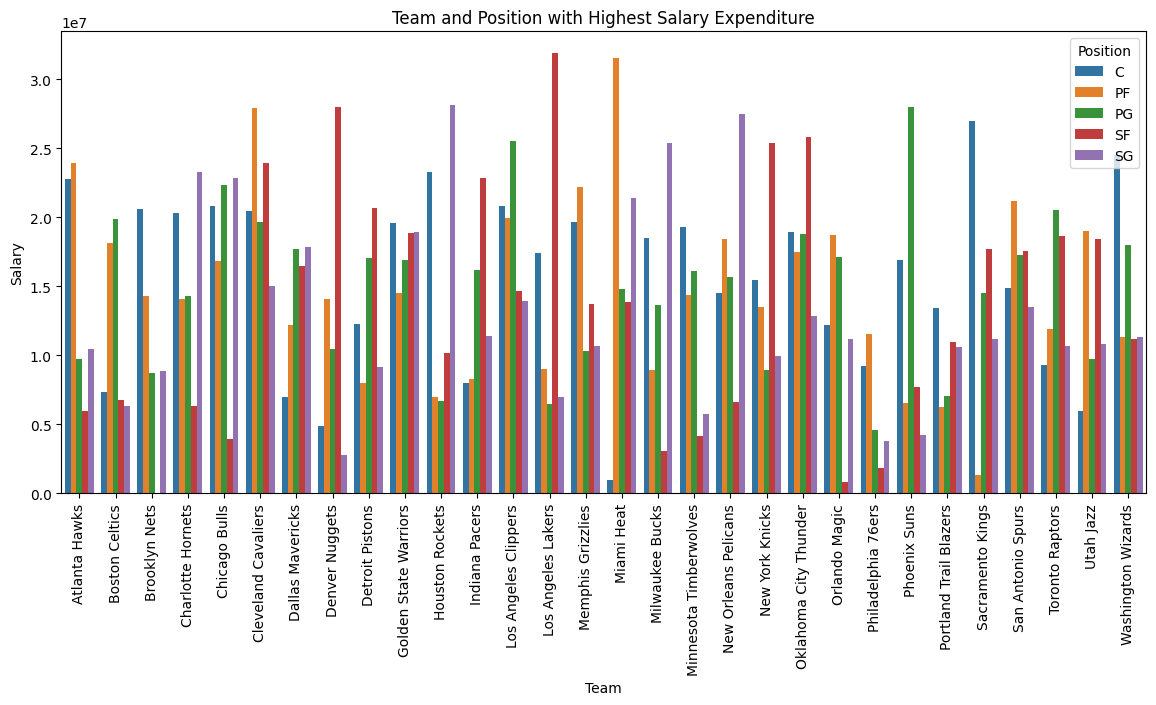

In [46]:
plt.figure(figsize=(14,6))
plt.title("Team and Position with Highest Salary Expenditure")
plt.xlabel("Team")
plt.ylabel("Salary")
plt.xticks(rotation=90)
sns.barplot(data=salary_team_position,y="Salary",x="Team",hue="Position")
plt.show()


#### Insights
* Employee distribution varies across different teams and positions.
* Certain team-position combinations have the highest salary expenditure.
* Salary expenditure is unevenly distributed across teams and positions.

### Correlation Between Age and Salary

In [47]:
# Investigate if there's any correlation between age and salary, and represent it visually.
correlation = df["Age"].corr(df["Salary"])

print("Correlation:", correlation)

Correlation: 0.2050096028480935


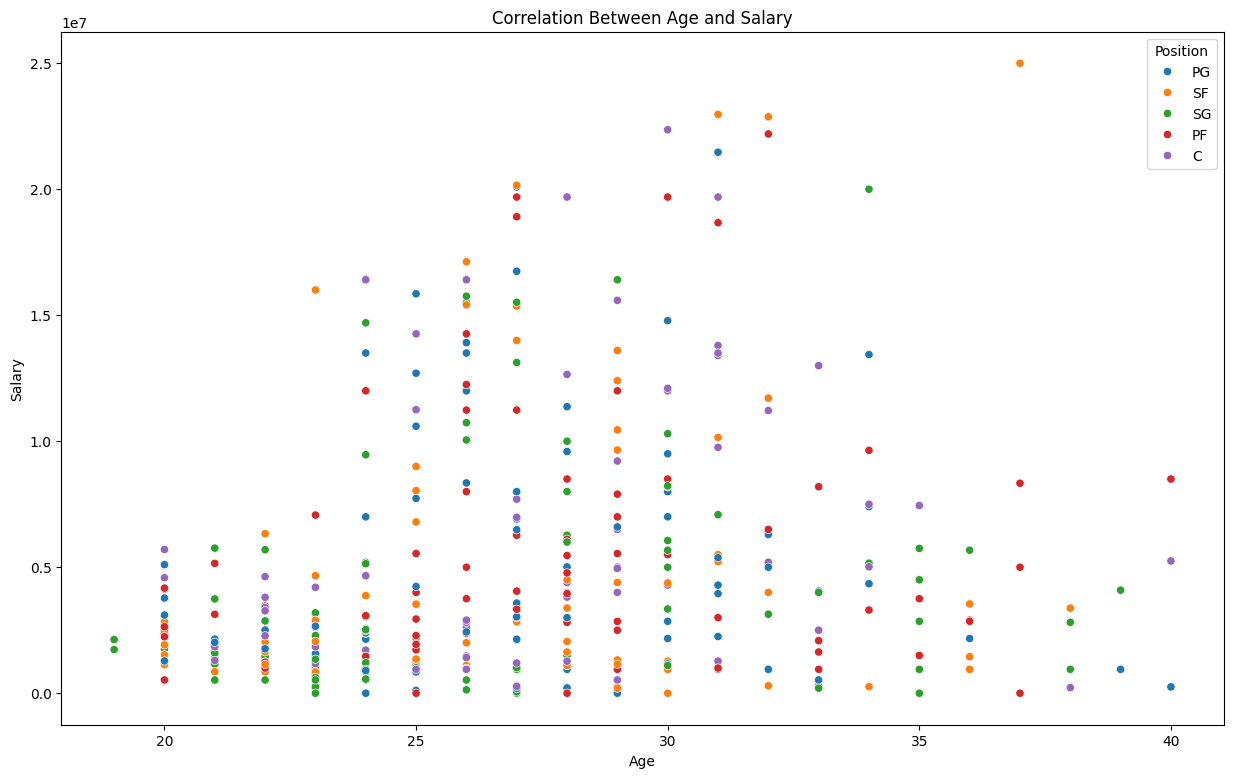

In [54]:
# Create heatmap
plt.figure(figsize=(15,9))

sns.scatterplot(data=df,x="Age",y="Salary",hue="Position")
plt.title("Correlation Between Age and Salary")

plt.show()

### Insight
 * Most employees/players fall within the age range of: 19 to 30 years
 * The salary distribution is highly uneven.
 * All job roles distributed throughuot the graph.